helpful resources
https://nathanhubens.github.io/posts/deep%20learning/2018/08/24/image-retrieval.html

https://www.kaggle.com/code/roblexnana/understanding-auto-encoder-on-mnist-digit-dataset

# load data

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

from sklearn.datasets import fetch_openml
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.decomposition import PCA

import tensorflow as tf
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Dense

In [ ]:
# Load MNIST
mnist = fetch_openml('mnist_784', version=1, as_frame=False)
X = mnist.data.astype('float32')

# Normalize (important)
scaler = MinMaxScaler()
X = scaler.fit_transform(X)

# Train / Test split
X_train, X_test = train_test_split(X, test_size=0.2, random_state=42)

print(X_train.shape, X_test.shape)

(56000, 784) (14000, 784)


# Visualize Data

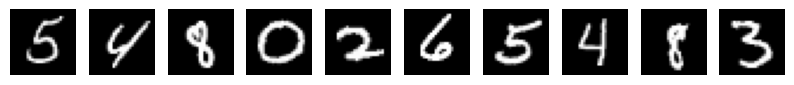

In [ ]:
def show_digits(images, n=10):
    plt.figure(figsize=(10, 2))
    for i in range(n):
        plt.subplot(1, n, i+1)
        plt.imshow(images[i].reshape(28,28), cmap='gray')
        plt.axis('off')
    plt.show()

show_digits(X_train)

# Autoencoder Arch

In [ ]:
input_dim = 784
latent_dim = 32

# Encoder
input_layer = Input(shape=(input_dim,))
encoded = Dense(128, activation='relu')(input_layer)
encoded = Dense(64, activation='relu')(encoded)
latent = Dense(latent_dim, activation='relu')(encoded)

# Decoder
decoded = Dense(64, activation='relu')(latent)
decoded = Dense(128, activation='relu')(decoded)
output_layer = Dense(input_dim, activation='sigmoid')(decoded)

# Models
autoencoder = Model(input_layer, output_layer)
encoder = Model(input_layer, latent)

# Compile
autoencoder.compile(optimizer='adam', loss='mse')

autoencoder.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       100,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 64)             │         2,112 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 128)            │         8,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 784)            │       101,136 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 222,384 (868.69 KB)

 Trainable params: 222,384 (868.69 KB)

 Non-trainable params: 0 (0.00 B)

# Training

In [ ]:
history = autoencoder.fit(
    X_train, X_train,
    validation_data=(X_test, X_test),
    epochs=20,
    batch_size=256,
    shuffle=True
)

Epoch 1/20
219/219 ━━━━━━━━━━━━━━━━━━━━ 4s 11ms/step - loss: 0.0663 - val_loss: 0.0375
Epoch 2/20
219/219 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - loss: 0.0316 - val_loss: 0.0266
Epoch 3/20
219/219 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - loss: 0.0244 - val_loss: 0.0224
Epoch 4/20
219/219 ━━━━━━━━━━━━━━━━━━━━ 3s 12ms/step - loss: 0.0211 - val_loss: 0.0199
Epoch 5/20
219/219 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - loss: 0.0188 - val_loss: 0.0179
Epoch 6/20
219/219 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - loss: 0.0171 - val_loss: 0.0166
Epoch 7/20
219/219 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - loss: 0.0161 - val_loss: 0.0157
Epoch 8/20
219/219 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step - loss: 0.0153 - val_loss: 0.0152
Epoch 9/20
219/219 ━━━━━━━━━━━━━━━━━━━━ 3s 11ms/step - loss: 0.0146 - val_loss: 0.0143
Epoch 10/20
219/219 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - loss: 0.0139 - val_loss: 0.0137
Epoch 11/20
219/219 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - loss: 0.0134 - val_loss: 0.0131
Epoch 12/20
219/219 ━━━━━━━━━━━━━━━━━━━━ 2s

# Reconstruct

438/438 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step


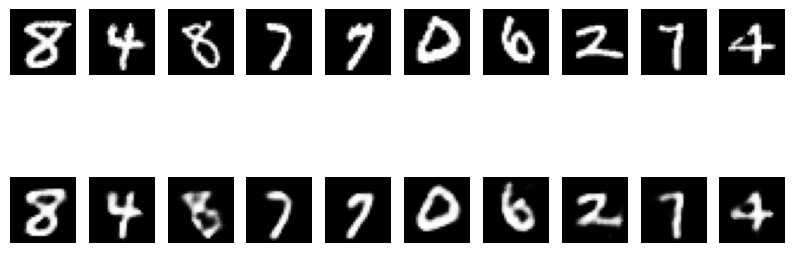

In [ ]:
reconstructed = autoencoder.predict(X_test)

n = 10
plt.figure(figsize=(10,4))

# Original
for i in range(n):
    plt.subplot(2, n, i+1)
    plt.imshow(X_test[i].reshape(28,28), cmap='gray')
    plt.axis('off')

# Reconstructed
for i in range(n):
    plt.subplot(2, n, i+1+n)
    plt.imshow(reconstructed[i].reshape(28,28), cmap='gray')
    plt.axis('off')

plt.show()

# Latent space visualization

438/438 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step


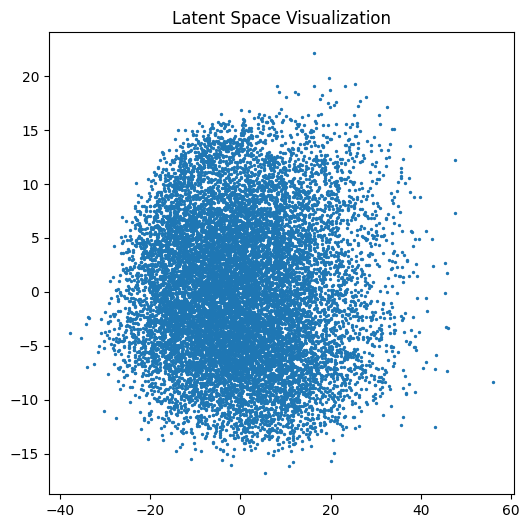

In [ ]:
# Encode test data
encoded_test = encoder.predict(X_test)

# Reduce to 2D using PCA
pca = PCA(n_components=2)
encoded_2d = pca.fit_transform(encoded_test)

plt.figure(figsize=(6,6))
plt.scatter(encoded_2d[:,0], encoded_2d[:,1], s=2)
plt.title("Latent Space Visualization")
plt.show()

# Image Retrieval (Cosine Similarity)

1750/1750 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step


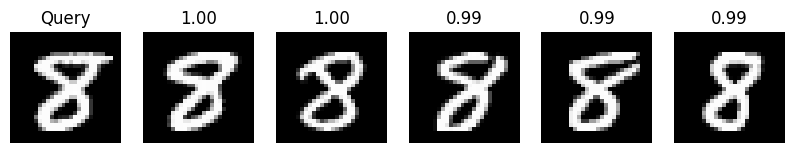

In [ ]:
# Encode train set
encoded_train = encoder.predict(X_train)

# Pick a query image
query = X_test[0].reshape(1, -1)
query_encoded = encoder.predict(query)

# Compute similarity
similarities = cosine_similarity(query_encoded, encoded_train)
top_k_idx = np.argsort(similarities[0])[-5:][::-1]

# Show results
plt.figure(figsize=(10,3))

# Query image
plt.subplot(1,6,1)
plt.imshow(query.reshape(28,28), cmap='gray')
plt.title("Query")
plt.axis('off')

# Top 5 similar
for i, idx in enumerate(top_k_idx):
    plt.subplot(1,6,i+2)
    plt.imshow(X_train[idx].reshape(28,28), cmap='gray')
    plt.title(f"{similarities[0][idx]:.2f}")
    plt.axis('off')

plt.show()

# Training Plot

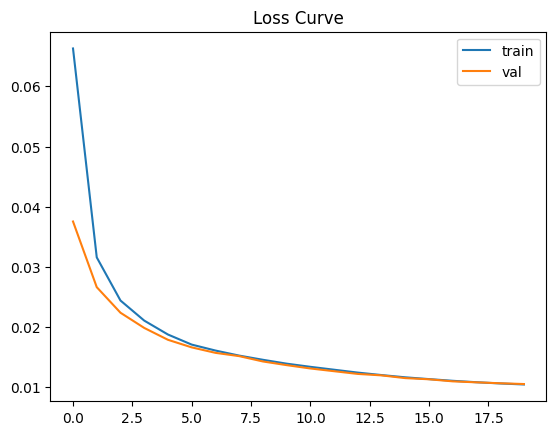

In [ ]:
plt.plot(history.history['loss'], label='train')
plt.plot(history.history['val_loss'], label='val')
plt.legend()
plt.title("Loss Curve")
plt.show()